In [1]:
import pandas as pd
import svy
import polars as pl
import matplotlib.pyplot as plt

In [2]:
path = '../data/processed/h1_analytic_sample.csv'
h1_df = pd.read_csv(path)
h1_df.shape

(3459, 181)

In [3]:
h1_df['cycle'].value_counts()

cycle
2007-2008    2034
2009-2010     763
2011-2012     662
Name: count, dtype: int64

In [4]:
h1_df.groupby('cycle')['WTSAF2YR'].describe()

,count,mean,std,min,25%,50%,75%,max
cycle,,,,,,,,
2007-2008,2034.0,91656.768573,72716.121676,9139.642,41339.95450,63932.6985,120992.62650,404655.623
2009-2010,763.0,81963.831999,63315.505791,11450.134,39183.37400,56685.4290,104024.76500,337218.920
2011-2012,662.0,94854.557742,88228.473073,10219.081,38630.00775,59353.2940,102529.40225,472452.362


In [5]:
h1_pooled = h1_df.assign(wtsaf2yr_pooled = h1_df['WTSAF2YR']/3)
h1_pooled

/var/folders/rs/yth10b8d4v1043_hxt3sv4x40000gn/T/ipykernel_31013/1523047953.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  h1_pooled = h1_df.assign(wtsaf2yr_pooled = h1_df['WTSAF2YR']/3)


,SEQN,LBXATG,LBXT3F,LBXT4F,LBDT4FSI,LBXTGN,LBDTGNSI,LBXTSH1,LBDTSH1S,LBXTPO,...,MCQ365A,MCQ365B,MCQ365C,MCQ365D,MCQ370A,MCQ370B,MCQ370C,MCQ370D,MCQ380,wtsaf2yr_pooled
0,41479.0,0.6,2.90,0.70,9.0,7.76,7.76,1.993,1.993,0.90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6661.200000
1,41485.0,0.6,3.60,0.80,10.3,9.25,9.25,1.293,1.293,0.40,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14480.479000
2,41489.0,4.2,2.80,1.00,12.9,0.23,0.23,1.944,1.944,6.90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20945.592000
3,41494.0,0.6,3.80,0.80,10.3,21.69,21.69,2.093,2.093,0.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10139.776333
4,41498.0,0.6,3.10,0.80,10.3,2.99,2.99,0.376,0.376,0.30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9347.907000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3454,71869.0,0.6,2.66,0.87,11.2,13.19,13.19,1.750,1.750,7.90,...,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,0.0,87504.113000
3455,71877.0,3.1,3.55,0.85,11.0,33.23,33.23,1.470,1.470,0.60,...,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,0.0,10292.776333
3456,71885.0,0.6,2.87,0.68,8.8,25.63,25.63,0.610,0.610,1.50,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,22440.753667
3457,71887.0,0.6,3.62,0.70,9.0,14.85,14.85,2.400,2.400,0.50,...,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,0.0,10778.895000


In [6]:
raw_2007_sum = h1_pooled.loc[h1_pooled['cycle'] == '2007-2008', 'WTSAF2YR'].sum()
print(f"(a) raw 2007-2008 only: {raw_2007_sum:,.0f}")

pooled_total = h1_pooled['wtsaf2yr_pooled'].sum()
print(f"(b) pooled, all cycles combined: {pooled_total:,.0f}")


(a) raw 2007-2008 only: 186,429,867
(b) pooled, all cycles combined: 103,920,663


In [7]:
h1_pooled = h1_pooled.assign(ft3_ft4_ratio = h1_pooled['LBXT3F'] / h1_pooled['LBXT4F'])
h1_pooled.describe()

/var/folders/rs/yth10b8d4v1043_hxt3sv4x40000gn/T/ipykernel_31013/358704701.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  h1_pooled = h1_pooled.assign(ft3_ft4_ratio = h1_pooled['LBXT3F'] / h1_pooled['LBXT4F'])


,SEQN,LBXATG,LBXT3F,LBXT4F,LBDT4FSI,LBXTGN,LBDTGNSI,LBXTSH1,LBDTSH1S,LBXTPO,...,MCQ365B,MCQ365C,MCQ365D,MCQ370A,MCQ370B,MCQ370C,MCQ370D,MCQ380,wtsaf2yr_pooled,ft3_ft4_ratio
count,3459.000000,3446.000000,3459.000000,3459.000000,3459.000000,3458.000000,3458.000000,3459.000000,3459.000000,3441.000000,...,662.000000,662.000000,662.000000,662.000000,662.000000,662.000000,662.000000,196.000000,3459.000000,3459.000000
mean,52792.729691,7.020342,3.249520,0.802388,10.336658,16.780373,16.780373,2.007181,2.007181,18.582005,...,1.655589,1.758308,1.702417,1.392749,1.413897,1.483384,1.460725,0.709184,30043.556743,4.156938
std,8589.254399,60.756761,0.654558,0.157862,2.042741,43.793406,43.793406,2.139225,2.139225,94.857808,...,0.475535,0.594133,0.457541,0.488731,0.492903,0.500102,0.498832,1.013811,24721.509539,0.965218
min,41479.000000,0.600000,1.860000,0.300000,3.900000,0.070000,0.070000,0.002000,0.002000,0.100000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3046.547333,1.380952
25%,45767.500000,0.600000,3.000000,0.700000,9.000000,6.050000,6.050000,1.120000,1.120000,0.300000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,13250.890000,3.625000
50%,50186.000000,0.600000,3.200000,0.800000,10.300000,10.490000,10.490000,1.633000,1.633000,0.600000,...,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000,20718.896667,4.101010
75%,59453.500000,0.600000,3.480000,0.900000,11.600000,17.880000,17.880000,2.450000,2.450000,1.500000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,38162.010500,4.624094
max,71909.000000,1404.100000,28.840000,4.800000,61.900000,2038.940000,2038.940000,69.836000,69.836000,2376.000000,...,2.000000,9.000000,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,157484.120667,36.050000


In [8]:
design = svy.Design(
    stratum='SDMVSTRA',
    psu='SDMVPSU',
    wgt='wtsaf2yr_pooled'
)

In [9]:
h1_pl = pl.from_pandas(h1_pooled)
sample = svy.Sample(h1_pl, design=design)

model_a = svy.GLM(sample)
model_a.fit(
    y='LBXTR',
    x=['ft3_ft4_ratio', 'RIDAGEYR', svy.Cat('RIAGENDR', ref=1)],
    family='gaussian',
)

print(model_a)

GLM: Gaussian (identity)
  Modeling : LBXTR
  n            : 3459          DF Residuals : 46
  Deviance     : 3.7926e+07    Scale        : 774004.5508
  AIC          : 42004.2768    BIC          : -
  R-squared    : 0.04111       R-sq (adj)   : 0.04027
  F-stat (adj) : 22.53915      Prob (F-adj) : <0.001

Coefficients:
  Term           Coef.      Std.Err.  t         P>|t|   [0.025     0.975]   
  -------------  ---------  --------  --------  ------  ---------  ---------
  _intercept_    45.96337   19.19678  2.39433   0.0208  7.32225    84.60449 
  ft3_ft4_ratio  14.87276   3.50232   4.24654   <0.001  7.82295    21.92257 
  RIDAGEYR       0.80354    0.13864   5.79591   <0.001  0.52447    1.08260  
  RIAGENDR_2.0   -26.93669  4.39471   -6.12935  <0.001  -35.78278  -18.09061


In [10]:
model_b = svy.GLM(sample)
model_b.fit(
    y='LBXTR',
    x=['ft3_ft4_ratio', 'RIDAGEYR', 'BMXBMI', svy.Cat('RIAGENDR', ref=1)],
    family='gaussian',
)

print(model_b)

GLM: Gaussian (identity)
  Modeling : LBXTR
  n            : 3413          DF Residuals : 45
  Deviance     : 3.6321e+07    Scale        : 751237.8346
  AIC          : 41346.3106    BIC          : -
  R-squared    : 0.06583       R-sq (adj)   : 0.06474
  F-stat (adj) : 27.09792      Prob (F-adj) : <0.001

Coefficients:
  Term           Coef.      Std.Err.  t         P>|t|   [0.025     0.975]   
  -------------  ---------  --------  --------  ------  ---------  ---------
  _intercept_    -20.81305  19.45866  -1.06960  0.2905  -60.00479  18.37870 
  ft3_ft4_ratio  14.15651   3.54865   3.98927   <0.001  7.00917    21.30386 
  RIDAGEYR       0.73010    0.13184   5.53786   <0.001  0.46457    0.99564  
  BMXBMI         2.57566    0.32765   7.86097   <0.001  1.91574    3.23559  
  RIAGENDR_2.0   -27.47121  4.33329   -6.33957  <0.001  -36.19890  -18.74351


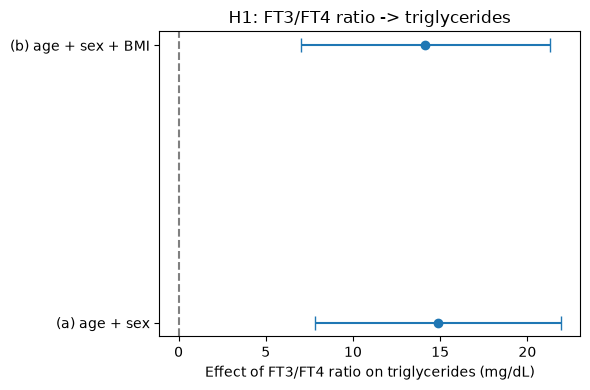

In [11]:
a_row = model_a.to_polars().filter(pl.col('term') == 'ft3_ft4_ratio').to_pandas()
a_row['model'] = '(a) age + sex'

b_row = model_b.to_polars().filter(pl.col('term') == 'ft3_ft4_ratio').to_pandas()
b_row['model'] = '(b) age + sex + BMI'

coef_comparison = pd.concat([a_row, b_row], ignore_index=True)
coef_comparison

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    x=coef_comparison['estimate'],
    y=coef_comparison['model'],
    xerr = [
        coef_comparison['estimate'] - coef_comparison['conf_low'],
        coef_comparison['conf_high'] - coef_comparison['estimate'],
    ],
    fmt='o',
    capsize=5
)

ax.axvline(0, linestyle='--', color='gray')
ax.set_xlabel('Effect of FT3/FT4 ratio on triglycerides (mg/dL)')
ax.set_title('H1: FT3/FT4 ratio -> triglycerides')
plt.tight_layout()
plt.show()